In [1]:
from pathlib import Path

import aw
from aw import reload
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import job_search.ai as ai
from job_search.config import VIEW_JOB_HTTPS, P_stem
import job_search.config as conf
import job_search.dataset as ds
# import job_search.jobs as jobs
import job_search.jobs as jb
import job_search.utils as utils
from job_search.jobs import COLS, cmask, disp
from job_search.scrape import DS_SF, HEALTH

In [2]:
jobs_df = jb.load_jobs('jobs.duckdb', overwrite=False)#.rename(columns={'title': 'title_', 'position': 'position_'})
jobs_mar = jobs_df.query('mar')
jobs2026 = jb.load_jobs2026('jobs.duckdb')

In [3]:
ds_df = jb.load_jobs(f'{DS_SF}.duckdb', overwrite=False)#.rename(columns={'title': 'title_', 'position': 'position_'})
ds_mar = ds_df.query('mar')
ds2026 = jb.load_jobs2026(f'{DS_SF}.duckdb')

In [4]:
health_df = jb.load_jobs(f'{HEALTH}.duckdb', overwrite=False)#.rename(columns={'title': 'title_', 'position': 'position_'})
health_mar = health_df.query('mar')
health2026 = jb.load_jobs2026(f'{HEALTH}.duckdb')

In [ ]:
aw.combo_sizes([set(ds_mar['_hash']), set(jobs_mar['_hash'])])

,0,1,Size,%
1,-,-,2119,100.0
2,Yes,-,1511,71.3
3,-,Yes,1007,47.5
4,Yes,Yes,399,18.8


In [148]:
aw.combo_sizes([set(ds_mar['_hash']), set(health_mar['_hash'])])

,0,1,Size,%
1,-,-,2838,100.0
2,Yes,-,1511,53.2
3,-,Yes,1475,52.0
4,Yes,Yes,148,5.2


In [147]:
aw.combo_sizes([set(ds_mar['_hash']), set(health_mar['_hash']), set(jobs_mar['_hash'])])

,0,1,2,Size,%
1,-,-,-,3441,100.0
2,Yes,-,-,1511,43.9
3,-,Yes,-,1475,42.9
4,-,-,Yes,1007,29.3
5,Yes,-,Yes,399,11.6
6,Yes,Yes,-,148,4.3
7,-,Yes,Yes,38,1.1
8,Yes,Yes,Yes,33,1.0


In [24]:
# jb.disp(jobs_mar, "lotus", 0)

In [22]:
jobs_mar.query('requisition_id == "drun11wbjc7tc457"').filter(like='yoe')

,min_industry_role_yoe,is_min_industry_role_yoe_not_mentioned,min_management_leadership_yoe,is_min_management_leadership_yoe_not_mentioned
2897,NaN,<NA>,NaN,True


In [3]:
JDF_COLS = ['days', 'title_', 'location', 'salary', 'onsite', 'full_time', 'company', 'yoe', '_hash', '_len', 'hours', 'position_', 'bay']
jdf = jb.load_jdf().rename(columns={'hash': '_hash', 'title': 'title_', 'position': 'position_'})[JDF_COLS]
jdf_hashes = jdf['_hash'].pipe(set)
# df = jobs_df.query('_hash in @jdf_hashes').reset_index(drop=True)
df = pd.merge(jdf[JDF_COLS], jobs_df, on='_hash', how='left')
# df['company_name'] = df['company_name'].fillna(df['company'])
# hash2position = dict(zip(jobs_df['_hash'], jobs_df['position']))

Date range:  Mar 02, 2026 to Apr 29, 2026 (58 days)
Mean date:   Apr 08, 2026
Median date: Apr 13, 2026


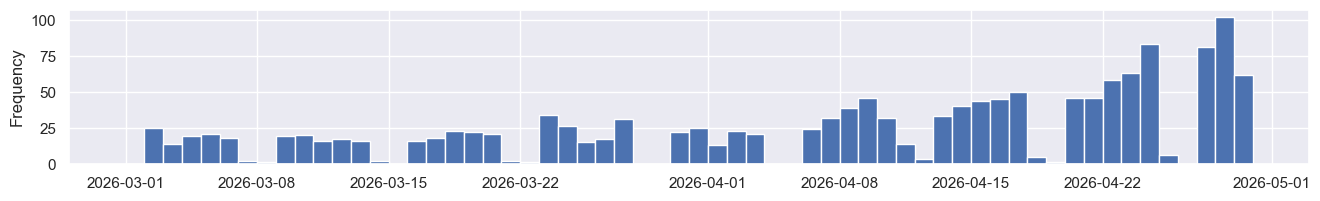

In [40]:
import job_search._AW_canes_visuals as cv
sns.set_theme()
_, ax = plt.subplots(figsize=(16,2))
# cv.plot_hist_date(jobs_mar['estimated_publish_date'], freq='D', verbose=True, ax=ax)
# cv.plot_hist_date(jobs2026['estimated_publish_date'], freq='D', verbose=True, ax=ax)
cv.plot_hist_date(health_mar['estimated_publish_date'], freq='D', verbose=True, ax=ax)
# cv.plot_hist_date(health2026['estimated_publish_date'], freq='D', verbose=True, ax=ax)

## EDA

In [ ]:
import pickle

# _hash = '42ep59wf5cocoez9'
_hash = 'drun11wbjc7tc457'
P_pkl = utils.paths(conf.P_DICT, glob=f'*{_hash}.html.pkl')[0]
with open(P_pkl, 'rb') as f:
    json_ = pickle.load(f)
# utils.paths(conf.P_DICT).iloc[0] #conf.P_DICT
json_

{'props': {'pageProps': {'job': {'id': 'ashby___lotushealth___34f0c039-c175-480c-8783-382cb3e4e6b0',
    'board_token': 'lotushealth',
    'source': 'ashby',
    'apply_url': 'https://jobs.ashbyhq.com/lotushealth/34f0c039-c175-480c-8783-382cb3e4e6b0',
    'source_and_board_token': 'ashby_lotushealth',
    'job_information': {'title': 'AI Quality & Safety Engineer',
     'job_title_raw': 'AI Quality & Safety Engineer',
     'description': '<h1>AI Quality &amp; Safety Engineer</h1><p style="min-height:1.5em"><strong>Location:</strong> San Francisco (onsite)</p><p style="min-height:1.5em"><strong>Compensation:</strong> $120–170K + variable equity</p><p style="min-height:1.5em"></p><h2>About Lotus AI</h2><p style="min-height:1.5em">Lotus AI is a primary care app that combines your medical records, AI, and real doctors to deliver free, personalized care (including prescriptions and referrals). We’re backed by Kleiner Perkins + CRV, and we’re a small team that ships fast.</p><p style="min-he

In [102]:
from job_search.config import VIEW_JOB_HTTPS
from textwrap import dedent
# _jobs_df = jobs_df.query('mar')
# _jobs_df = health_df.query('estimated_publish_date >= "2026-04-01"')
_jobs_df = health_mar
# mask = cmask('protein')
mask = jb.text_mask('rwd|real.?world data', _jobs_df)

mask = mask.reindex(_jobs_df.index)
for title, comp, hash in _jobs_df[mask][['title', 'company_name', '_hash']].pipe(aw.itertuples):
    print(dedent(f"""
        {title}
        @ {comp}
        {VIEW_JOB_HTTPS}{hash}"""))


AI Scientist
@ GE HealthCare
https://hiring.cafe/viewjob/5lf3ru00xzlsm98t

Principal Data Scientist
@ Roche
https://hiring.cafe/viewjob/7y46lq6wg542ldzt

Analyst-Data Products
@ Elevance Health
https://hiring.cafe/viewjob/babq2rodsvqmagri

Sr. Data Scientist, Outcomes Research
@ Tempus AI
https://hiring.cafe/viewjob/o7v2inrsbtletgwd

Risk Adjustment Data Analyst
@ Datavant
https://hiring.cafe/viewjob/vhs463irzw8z54da

Senior Data Scientist II
@ Helix
https://hiring.cafe/viewjob/xbksydl5q3suhb48

BI Developer
@ University of Wisconsin–Madison
https://hiring.cafe/viewjob/sgd5xt2q3j014oa6

Data & Analytics – Upcoming Opportunities at Surescripts
@ Surescripts
https://hiring.cafe/viewjob/svzd8iz6uxllripj

Director, Data Science and Digital Health - Hematology, Oncology
@ Johnson & Johnson
https://hiring.cafe/viewjob/qxu02gog6d4dfryz

Senior Data Engineer
@ Formation Bio
https://hiring.cafe/viewjob/w7xt1xr0xhowhl4b

Data Scientist - Portfolio Optimization
@ Formation Bio
https://hiring.caf

In [7]:
jb.disp(health_df.query('mar'), 'protein', 5, llm=True)

N,Total,%
21,1475,1.4


6 of 21: https://hiring.cafe/viewjob/ijoq2qgh0rjoa0ax


**Top 7 Job Requirements (Domain Area, Expertise, Soft Skills):**  
- Deep expertise in deep learning and AI systems, particularly in biology and scientific domains  
- Experience designing and scaling foundation models (e.g., protein language models, structure prediction)  
- Strong background in reinforcement learning, reasoning, and multi-agent systems  
- Proficiency in large-scale AI training pipelines and model architecture design  
- Experience with scientific data at scale and AI-driven data curation  
- Ability to work across ambiguous, high-impact, research-driven problems with rapid iteration  
- Excellent communication skills to bridge technical AI systems and scientific research communities  

**Top 7 Nice-to-Haves:**  
- Background in mechanistic interpretability or biological model analysis  
- Experience with imaging foundation models or microscopy datasets  
- Familiarity with open science practices and collaborative research ecosystems  
- Hands-on experience with AI-driven scientific discovery or lab integration  
- Track record of publishing or open-source contributions in AI or biology  
- Experience with AI systems that evaluate real-world biological outcomes  
- Strong interdisciplinary mindset combining AI, biology, and scientific reasoning

,436
company_name,Chan Zuckerberg Biohub
title,"Research Engineer, AI"
estimated_publish_date,2026-04-08 21:09:43
requirements_summary,Experience building and scaling deep learning systems; strong engineering and scientific fundamentals; comfort with ambiguity; excellent communication across technical and scientific audiences.
job_category,Research and Development (R&D)
workplace_type,Hybrid
formatted_workplace_location,Redwood City or New York City
technical_tools,['Deep learning' 'Distributed systems' 'RL' 'Multi-agent systems' 'AI foundation models']
role_activities,['Build AI systems' 'Design model architectures' 'Scale pre-training pipelines']
seniority_level,No Prior Experience Required


In [61]:
jb.disp(jobs_df.query('mar'), 'protein', 5, llm=False)

N,Total,%
10,1007,1.0


6 of 10: https://hiring.cafe/viewjob/auc02qkvyougmn9w


,2862
company_name,Xaira Therapeutics
title,BioMedical AI Research Engineer
estimated_publish_date,2026-03-31 20:14:54
requirements_summary,"Design and deploy agentic AI systems for biomedical data integration and discovery; strong ML, LLMs, Python, and biomedical data experience."
job_category,Research and Development (R&D)
workplace_type,Onsite
formatted_workplace_location,"South San Francisco, California, United States"
technical_tools,['Python' 'PyTorch' 'JAX' 'TensorFlow' 'Knowledge Graphs' 'LLMs']
role_activities,['design architectures' 'build agents' 'integrate data']
seniority_level,Mid Level


In [62]:
jb.disp(jobs_df.query('mar'), 'real-?world data', 3, llm=True)
# jobs.disp(jobs_df.query('feb'), 'dbt')

N,Total,%
11,1007,1.1


4 of 11: https://hiring.cafe/viewjob/ueblett9js51emdg


**Top 7 Essential (Domain Area, Expertise, Soft Skills):**  
- **Domain Area:** Risk, Compliance, Identity, Servicing, Agentic, Data Platforms (across Consumer, SMB, and Enterprise)  
- **Expertise:** Advanced analytics, machine learning modeling, data engineering, ETL pipelines, A/B testing  
- **Technical Skills:** Proficiency in SQL, Python, BigQuery, Tableau, Power BI, Jupyter, Hadoop, Hive  
- **Data Focus:** Analysis of high-volume, high-dimensional real-world data with scalable, measurable business outcomes  
- **Cross-Functional Collaboration:** Experience partnering with Product, Strategy, Business, and Global Risk teams  
- **Project Leadership:** End-to-end ownership of data science projects from ideation to delivery  
- **Data Storytelling & Communication:** Ability to translate complex insights into clear, actionable insights for technical and executive audiences  

**Top 7 Nice-to-Haves:**  
- Experience in fintech, banking, or financial crimes/Risk & Regulatory environments  
- Background in Second Line of Defense or customer protection functions  
- Demonstrated success in delivering data-driven insights to influence business decisions  
- Experience building executive dashboards and visualizations using Looker or advanced BI tools  
- Experience with agile, fast-paced, results-driven environments and product thinking  
- Strong mentorship and team development skills to foster a culture of learning  
- Background in scalable data solutions with a focus on data quality and integrity

,2634
company_name,PayPal
title,Staff Data Scientist
estimated_publish_date,2026-03-20 00:00:00
requirements_summary,5+ years of experience in analytics/data science; strong SQL and Python; experience with BI tools and data pipelines.
job_category,Data and Analytics
workplace_type,Hybrid
formatted_workplace_location,Austin or San Jose
technical_tools,['SQL' 'Python' 'BigQuery' 'Tableau' 'Power BI' 'Looker']
role_activities,['Lead projects' 'Develop models' 'Analyze data']
seniority_level,Senior Level


In [6]:
print(ai.load_resume38(verbose=False))

**Data Scientist**
Full-stack Data Scientist with 5+ years of experience delivering real-world insights and solutions end-to-end from ideation to deployment in the healthcare and technology sectors. Expansive skill set with a strong focus on AI, machine learning, natural language processing, and software engineering. Enthusiastic collaborator, working with stakeholders to support data-driven decision-making and partnering with cross-functional teams to productionize machine learning models. Passionate about solving real business challenges and delighting end users.

## **SKILLS**

- **Languages and Programming:** Python, SQL, R, JavaScript, Java, C++
- **Python for Data Science:** Pandas, NumPy, Scikit-learn, PyTorch, Jupyter Notebook
- **Visualization and Communication:** Plotly, Matplotlib, Streamlit, Figma, stakeholder reporting
- **Statistical Modeling:** Experimental design, Propensity score matching, Causal inference, Hypothesis testing
- **Machine Learning:** Regression, SVM, Ra

In [ ]:
jb.hash2md("p0w266aywbqx8boy", verbose=True)

**Company Description:**

**Department:** DataSF  
**Job class:** 1043 Senior Data Engineer  
**Salary range:** $153,686/year - $193,388/year   
**Role type:** Permanent Exempt  
**Hours:** Full-time. The department has a hybrid work schedule.

**About:**  
Permanent Exempt: This is an Exempt position excluded by the Charter from the competitive Civil Service examination process, pursuant to the City and County of San Francisco, Charter Section 10.104. It is considered "at will" and shall serve at the discretion of the Appointing Officer.    
  
Application Opening: **Monday, February 23, 2026**  
Application Closing: Interested candidates are encouraged to apply as soon as possible, as this job announcement will close at any time, but not earlier than **Sunday, March 2, 2026 at 11:59pm PST**

**As part of the application process, you must also complete a Supplemental Questionnaire using this link by the filing deadline: <https://forms.office.com/g/PgvQyRjYdX>**

**The Office of the Ci

In [66]:
jb.disp(jobs_df, 'datasf', 1)

N,Total,%
2,3289,0.1


2 of 2: https://hiring.cafe/viewjob/hzcvpa47m38gkbt2


,2498
company_name,City and County of San Francisco
title,Senior Data Engineer (1043) - DataSF
estimated_publish_date,2026-01-05 17:21:12.207000
requirements_summary,"3+ years data engineering experience; strong Snowflake, Python, SQL, data pipelines; Terraform; public sector interest."
job_category,Data and Analytics
workplace_type,Hybrid
formatted_workplace_location,"San Francisco, California, United States"
technical_tools,['Snowflake' 'BigQuery' 'Databricks' 'dbt' 'Python' 'Terraform' 'Airflow' 'Dagster' 'Kafka' 'Kinesis' 'Snowpipe']
role_activities,['Platform Administration' 'Pipeline Development' 'Infrastructure as Code']
seniority_level,Senior Level


In [78]:
rwd_mask = jb.text_mask('rwd|real.?world data')
# rwd_mask = jobs.cmask('rwd|real[- ]world data')
# jobs.perc(rwd_mask)
# jb.disp(jobs_df.query('estimated_publish_date >= "2026-03-01"'), rwd_mask)
jb.disp(jobs_df.query('estimated_publish_date >= "2026-04-01"'), rwd_mask, 3)
# jobs.disp(jobs_df, rwd_mask)

N,Total,%
4,414,1.0


4 of 4: https://hiring.cafe/viewjob/kmwxlsl5saf7zgjv


,3240
company_name,Trinity Life Sciences
title,"Data Scientist, AI Engineering"
estimated_publish_date,2026-04-20 00:00:00
requirements_summary,Bachelor’s or Master’s in a quantitative field; 3-6 years data science/analytics; Python/R; SQL; healthcare data experience; strong communication.
job_category,Data and Analytics
workplace_type,Hybrid
formatted_workplace_location,Waltham or San Francisco or New York or Princeton or Philadelphia
technical_tools,['Python' 'R' 'SQL' 'AWS' 'GCP' 'Azure' 'Git']
role_activities,['Design models' 'Lead delivery' 'Present findings']
seniority_level,Mid Level


In [98]:
jb.hash2md('7y46lq6wg542ldzt', jobs_df=health_df)

"**The Opportunity**\n\nThe Principal Data Scientist of the Technical Institute (TI) is a member of the Evidence for Access (E4A) unit in the US Public Affairs and Access department. He/she serves as the TI point of contact for E4A health economics outcomes research (HEOR) members to design and execute observational research using in-house real-world data (RWD). This role involves hands-on coding in analytics software. Economic modelling experience is a plus.\n\n**Key responsibilities include:**\n\n* Collaborate with E4A HEOR and health policy project owners to identify the appropriate in-house databases (e.g., claims/survey/electronic medical record) and design appropriate methodology to answer specific research questions and to address business needs.\n* Participate in E4A strategic planning and lead the execution of in-house RWD studies of E4A HEOR and health policy project owners.\n* Develop and/or oversee research protocol and statistical analysis plan. Recommend and implement app

In [101]:
_jobs_df = health_df.query('estimated_publish_date >= "2026-04-01"')
rwd_mask = jb.text_mask('rwd|real.?world data', _jobs_df)
jb.disp(_jobs_df, rwd_mask, 0)

N,Total,%
13,1012,1.3


1 of 13: https://hiring.cafe/viewjob/5lf3ru00xzlsm98t


,104
company_name,GE HealthCare
title,AI Scientist
estimated_publish_date,2026-04-28 00:00:00
requirements_summary,"Master’s or PhD in STEM with 3+ years research; publications as first author on LLM/SSL; experience with large-scale AI and high-level languages (Python, C++)."
job_category,Research and Development (R&D)
workplace_type,Onsite
formatted_workplace_location,"Bellevue, Washington, United States"
technical_tools,['Python' 'C++' 'PyTorch' 'TensorFlow' 'DeepSpeed' 'HuggingFace' 'Megatron' 'PyTorch Lightning' 'Spark' 'Hadoop' 'MLOps']
role_activities,['develop models' 'evaluate performance' 'prototype software']
seniority_level,Senior Level


### CreatorIQ

In [ ]:
import re
_technical_tools = ['NLP', r'LLMs?', r'Agent/+\b', 'SQL', 'Pandas', r'(?<=\s)CreatorIQ']
_md = jd = Path('jd.md').read_text()
_replace_list = [*_technical_tools, 'AI']
for tool in _replace_list:
    # _md = re.sub(rf"\b{tool}\b", f'<span style="color: rebeccapurple">{tool}</span>', _md)
    _md = re.sub(rf"\b({tool})\b", rf'<span style="color: rebeccapurple">\1</span>', _md)

In [12]:
_markdown = f'<div style="font-size:16px;max-width:45rem;margin:0 auto;">{str(jd)}</div>'
_markdown

'<div style="font-size:16px;max-width:45rem;margin:0 auto;">## (Metadata)\n\n- **Location:** San Francisco, Chicago, Los Angeles, New York\n- **Employment Type:** Full time\n- **Location Type:** Remote\n- **Department:** Product\n- **Compensation:** $145K – $166K\n\n## Job Description\n\nCreatorIQ is the operating system for creator-led growth trusted by more than 1,300 global brands and agencies.\n\nWe’re on a mission to make businesses more human, and humans more impactful. We operate by our values — be intentional, pursue excellence every day, embrace the journey together, and be a good human — every day. CreatorIQ has earned the title of best companies to work for in multiple programs, including BuiltIn LA and NY. It’s been named a Fastest-Growing Company in North America on the Deloitte Technology Fast 500™ for four years, was named a leader in IDC MarketScape: Worldwide Influencer Marketing Platforms for Large Enterprises in 2025, was named a Leader by The Forrester New Wave™: In

In [ ]:
# ai.llm_extract(jd, verbose=True)
print(ai.llm_extract(jd, verbose=False))

In [ ]:
jb._display_md(_md)

<div style="font-size:16px;max-width:45rem;margin:0 auto;">## (Metadata)

- **Location:** San Francisco, Chicago, Los Angeles, New York
- **Employment Type:** Full time
- **Location Type:** Remote
- **Department:** Product
- **Compensation:** $145K – $166K

## Job Description

<span style="color: rebeccapurple">CreatorIQ</span> is the operating system for creator-led growth trusted by more than 1,300 global brands and agencies.

We’re on a mission to make businesses more human, and humans more impactful. We operate by our values — be intentional, pursue excellence every day, embrace the journey together, and be a good human — every day. <span style="color: rebeccapurple">CreatorIQ</span> has earned the title of best companies to work for in multiple programs, including BuiltIn LA and NY. It’s been named a Fastest-Growing Company in North America on the Deloitte Technology Fast 500™ for four years, was named a leader in IDC MarketScape: Worldwide Influencer Marketing Platforms for Large Enterprises in 2025, was named a Leader by The Forrester New Wave™: Influencer Marketing Solutions, and has been consistently recognized by G2 as a Leader, and is rated 5 stars on Influencer MarketingHub. We operate in a flexible work model that combines both in-person and remote work to boost collaboration, enhance innovation, and adapt to individual work styles.

We're seeking passionate, innovative minds to join our journey. Be a part of our dynamic team and let's transform the industry together!

## **Data Scientist**

As a Data Scientist on our Data Science team, you will play a pivotal role in extracting meaning from the millions of pieces of content generated by creators every day. You will focus primarily on improving robust, scalable classification and language models that categorize content, detect trends, and ensure brand safety. While your core focus will be on foundational Machine Learning and <span style="color: rebeccapurple">NLP</span>, you will also have the opportunity to experiment with <span style="color: rebeccapurple">LLM</span>-backed and agentic applications.

**In this role, you’ll get to:**

- **Build & Refine Classifiers:** Develop and maintain multi-class text classification models to categorize creator content, brand mentions, and sentiment with high precision and recall.
- **Analyze Content Semantics:** Utilize Natural Language Processing (<span style="color: rebeccapurple">NLP</span>) techniques (topic modeling, sentiment analysis, entity extraction) to structure unstructured data from social platforms like TikTok, Instagram, and YouTube.
- **Bridge ML and GenAI:** Experiment with Large Language Models (<span style="color: rebeccapurple">LLMs</span>) to augment training data, perform few-shot classification, or summarize complex creator data, interfacing with the engineering team to bring these concepts to life.
- **Own the Data Lifecycle:** Write efficient code to clean, preprocess, and tokenize large text datasets, ensuring high-quality inputs for your models.
- **Measure & Optimize:** Work with MLOps to constantly evaluate model performance using standard metrics (F1 score, AUC-ROC) and work to reduce latency for real-time inference needs.
- **Build & Integrate:** Collaborate with engineering to integrate measurement loops into our broader infrastructure (AWS/GCP), ensuring our model lifecycle is automated and observable.

**Who you are and what you’ll need for this position:**

- **<span style="color: rebeccapurple">NLP</span> Practitioner:** You have 2-4 years of experience building and deploying <span style="color: rebeccapurple">NLP</span> models. You are comfortable with concepts like tokenization, word embeddings, and topic modeling.
- **Machine Learning Foundation:** You have a strong grasp of classical ML algorithms (Random Forest, XGBoost, SVM) and know when to use a simple logistic regression versus a deep learning approach.
- **Python Proficiency:** You are fluent in Python and its data stack (<span style="color: rebeccapurple">Pandas</span>, NumPy, Scikit-learn). Experience with libraries like Hugging Face or Spacy is a major plus.
- **Curious about <span style="color: rebeccapurple">LLMs</span>:** While you are grounded in traditional ML, you have a working knowledge of <span style="color: rebeccapurple">LLM</span> APIs (OpenAI, Anthropic) and prompt engineering, and you are eager to learn how to integrate them into production workflows.
- **Data Driven:** You are comfortable writing complex <span style="color: rebeccapurple">SQL</span> queries to pull your own data and verify your hypotheses.
- **Team Player:** You can explain complex technical concepts to non-technical stakeholders and collaborate effectively with MLOps engineers to get your models into production.

Confidence can sometimes hold us back from applying for a job. But we'll let you in on a secret: there's no such thing as a 'perfect' candidate. Have 50% of the criteria? Excited about this opportunity? Passionate about what we do at <span style="color: rebeccapurple">CreatorIQ</span>? Please apply! <span style="color: rebeccapurple">CreatorIQ</span> is a place where everyone can grow.

**What you will get from us:**

- People: work with talented, collaborative, and friendly people who love what they do.
- Guidance: utilize our learning platform to fully get the training and tools you’ll need to become successful here from your first day with us.
- Surprise meal stipends: work from home can’t stop the enjoyment of someone else making a meal for you!
- Work/life harmony: 15 days vacation, floating and set holidays, wellness allowance, and paid parental leave.
- Whole Health Package: medical, dental, vision, life, disability insurance, and more.
- Savings: a 401k (USA) plan to help you plan ahead.
- Work from home stipend: to assist you in setting up a home office that works for you (or buy a new dog leash - your choice!).

**Who we are:**

<span style="color: rebeccapurple">CreatorIQ</span> is the operating system for creator-led growth. Trusted by more than 1,300 global brands and agencies—including Burson, Delta Air Lines, Google, LVMH, Nestlé, and Sephora—CreatorIQ unifies creator marketing across paid, owned, earned, commerce, and community into one seamless, enterprise-grade ecosystem. With industry-leading intelligence infrastructure, rigorous compliance and security standards, and integrations with Meta, Snapchat, TikTok, YouTube, and more, <span style="color: rebeccapurple">CreatorIQ</span> empowers brands and agencies to harness the creator economy as a strategic growth engine. <span style="color: rebeccapurple">CreatorIQ</span> is a global company headquartered in Los Angeles with offices in Austin, New York, San Francisco, London, Manila, and Warsaw. Learn more at [](http://www.creatoriq.com/)[www.creatoriq.com](http://www.creatoriq.com/) and follow us on [LinkedIn](https://www.linkedin.com/company/creatoriq) and [Instagram](https://www.instagram.com/creatoriq).

At <span style="color: rebeccapurple">CreatorIQ</span>, we believe that diversity is the key to unlocking our full potential. We are committed to fostering an inclusive, equitable, and empowering work environment where everyone can thrive, regardless of race, ethnicity, gender, sexual orientation, age, religion, disability, or any other characteristic that makes us unique. By embracing our core values of being intentional, pursuing excellence every day, embracing the journey together, being a good human, and staying focused on what’s important, we create an atmosphere that promotes collaboration and growth. Join us to celebrate differences, innovate together, and be a part of a business that is disrupting the marketing industry.

**Compensation, benefits, and beyond:**

We understand that a comprehensive benefits package plays a significant role in your overall compensation. To gain more insight into the various components of our total compensation, [we invite you to review our benefits and perks](https://creatoriq.notion.site/What-you-ll-get-from-us-at-CreatorIQ-d252de0c5995417f89b564cfdbbc4b24?pvs=4).</div>

## EDA

In [107]:
health2026['health'].pipe(aw.perc)

N,Total,%
329,1855,17.7


In [128]:
health_df = jb.load_jobs(HEALTH)

In [131]:
health_df['health'].pipe(aw.perc)

N,Total,%
1885,2229,84.6


In [129]:
health_df.query('jan').drop_duplicates(subset='company_name')['company_activities'].explode().pipe(aw.vcounts)

,company_activities,N,%
1,Healthcare data analytics,51,1.1
2,Emergency medical services,34,0.7
3,Medical device manufacturing,28,0.6
4,Revenue cycle management,25,0.5
5,Primary medical care,24,0.5
6,Healthcare software development,22,0.5
7,Clinical research,18,0.4
8,Healthcare services,17,0.4
9,Drug discovery,17,0.4
10,Medical education,16,0.3
